In [4]:
matrix=[
    [2, 2, 32, 34, 18, 28, 32, 24, 16, 28],
    [3, 9, 102, 105, 51, 84, 90, 54, 42, 90],
    [8, 9, 137, 145, 76, 119, 135, 99, 67, 120],
    [3, 7, 84, 87, 43, 70, 76, 48, 36, 74],
    [6, 1, 51, 57, 34, 49, 61, 57, 33, 44],
    [2, 7, 77, 79, 38, 63, 67, 39, 31, 68],
    [7, 6, 103, 110, 59, 91, 105, 81, 53, 90],
    [8, 8, 128, 136, 72, 112, 128, 96, 64, 112],
    [2, 7, 77, 79, 38, 63, 67, 39, 31, 68],
    [4, 5, 73, 77, 40, 63, 71, 51, 35, 64]
]

In [5]:
# prompt: This list represents rows of a matrix for instance for example, first element in the list represents the first row and this repsents a 10x10 matrix and I know that 3rd, 4th, and upto 10th is the linear combination of the 1st and 2nd columns, find out the linear combination

import numpy as np

matrix = [
    [2, 2, 32, 34, 18, 28, 32, 24, 16, 28],
    [3, 9, 102, 105, 51, 84, 90, 54, 42, 90],
    [8, 9, 137, 145, 76, 119, 135, 99, 67, 120],
    [3, 7, 84, 87, 43, 70, 76, 48, 36, 74],
    [6, 1, 51, 57, 34, 49, 61, 57, 33, 44],
    [2, 7, 77, 79, 38, 63, 67, 39, 31, 68],
    [7, 6, 103, 110, 59, 91, 105, 81, 53, 90],
    [8, 8, 128, 136, 72, 112, 128, 96, 64, 112],
    [2, 7, 77, 79, 38, 63, 67, 39, 31, 68],
    [4, 5, 73, 77, 40, 63, 71, 51, 35, 64]
]

# Convert the matrix to a NumPy array for easier calculations
matrix_np = np.array(matrix)

# Extract the first two columns and the columns from the 3rd to the 10th
A = matrix_np[:, :2]
B = matrix_np[:, 2:]

# Calculate the linear combination coefficients using least squares
coefficients = np.linalg.lstsq(A, B, rcond=None)[0]

print("Linear Combination Coefficients:")
coefficients

Linear Combination Coefficients:


array([[7., 8., 5., 7., 9., 9., 5., 6.],
       [9., 9., 4., 7., 7., 3., 3., 8.]])

In [6]:
# anime recommendation system - basic requirements
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

anime = pd.read_csv('/content/sample_data/anime.csv')
rating = pd.read_csv('/content/sample_data/rating.csv')

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [9]:
rating.head()

,user_id,anime_id,rating
0,1,20,-1.0
1,1,24,-1.0
2,1,79,-1.0
3,1,226,-1.0
4,1,241,-1.0


In [10]:
anime.describe()
rating.describe()

,user_id,anime_id,rating
count,238659.000000,238659.000000,238658.000000
mean,1217.853259,11159.673036,6.036567
std,690.054295,9187.834404,3.845975
min,1.000000,1.000000,-1.000000
25%,621.000000,2762.000000,5.000000
50%,1212.000000,9941.000000,7.000000
75%,1798.000000,17389.000000,9.000000
max,2462.000000,34325.000000,10.000000


In [11]:
rating.rating.value_counts()

,count
rating,
8.0,50941
-1.0,49475
7.0,40633
9.0,40126
10.0,28192
6.0,17319
5.0,7116
4.0,2646
3.0,1116


In [12]:
# I'm not sure what the "-1" mean because the ratings goes from 1 up to 10.
# Maybe it means, that no rating are available.
# Therefore we will delete the rows with "-1" in rating
rating = rating[rating["rating"] != -1]

In [13]:
print(f"anime.csv - rows: {anime.shape[0]}, columns: {anime.shape[1]}")
print(f"rating.csv - rows: {rating.shape[0]}, columns: {rating.shape[1]}")

anime.csv - rows: 12294, columns: 7
rating.csv - rows: 189184, columns: 3


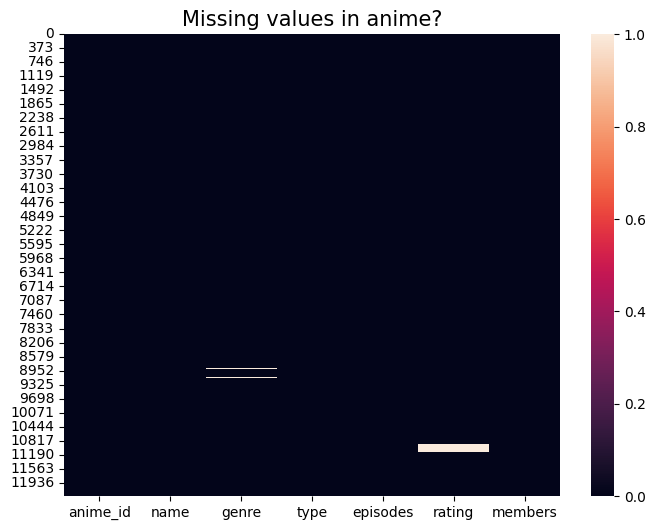

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(anime.isnull())
plt.title("Missing values in anime?", fontsize = 15)
plt.show()

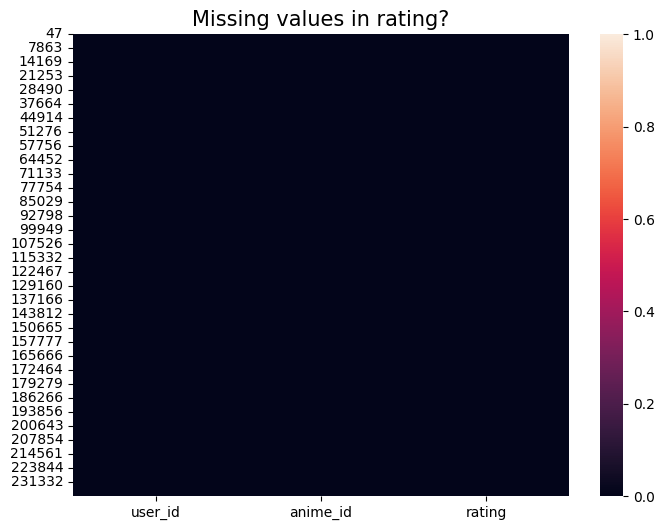

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(rating.isnull())
plt.title("Missing values in rating?", fontsize = 15)
plt.show()

In [16]:
#preparing the data
# Merge anime and rating using "anime_id" as reference
# Keep only the columns we will use
df = pd.merge(rating,anime[["anime_id","name"]], left_on = "anime_id", right_on = "anime_id").drop("anime_id", axis = 1)
df.head()

# keeping genres, types and others

df = pd.merge(rating,anime[["anime_id","name", "genre", "type", "episodes"]], left_on = "anime_id", right_on = "anime_id")
display(df.head())

,user_id,anime_id,rating,name,genre,type,episodes
0,1,8074,10.0,Highschool of the Dead,"Action, Ecchi, Horror, Supernatural",TV,12
1,1,11617,10.0,High School DxD,"Comedy, Demons, Ecchi, Harem, Romance, School",TV,12
2,1,11757,10.0,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25
3,1,15451,10.0,High School DxD New,"Action, Comedy, Demons, Ecchi, Harem, Romance,...",TV,12
4,2,11771,10.0,Kuroko no Basket,"Comedy, School, Shounen, Sports",TV,25


In [17]:
# Extract data for specific anime titles
one_piece_data = df[df['name'] == 'One Piece']
naruto_data = df[df['name'] == 'Naruto']
bleach=df[df['name'] == 'Bleach']

print("Data for One Piece:")
display(one_piece_data.head())

print("\nData for Naruto:")
display(naruto_data.head())

print("\nData for Bleach:")
display(bleach.head())

Data for One Piece:


,user_id,anime_id,rating,name,genre,type,episodes



Data for Naruto:


,user_id,anime_id,rating,name,genre,type,episodes
5,3,20,8.0,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220
101,5,20,6.0,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220
1651,21,20,8.0,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220
2077,28,20,9.0,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220
2364,34,20,9.0,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220



Data for Bleach:


,user_id,anime_id,rating,name,genre,type,episodes
141,5,269,3.0,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366
899,8,269,9.0,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366
2346,33,269,9.0,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366
2369,34,269,10.0,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366
2469,38,269,8.0,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366


In [18]:
# Count the number of ratings for each anime
count_rating = df.groupby("name")["rating"].count().sort_values(ascending = False)
count_rating

,rating
name,
Sword Art Online,1193
Shingeki no Kyojin,1171
Death Note,1128
Angel Beats!,914
Mirai Nikki (TV),832
...,...
30-sai no Hoken Taiiku Specials,1
Zettai Karen Children Gentei Kaikin!! OVA Chou Sakidori Special!!,1
Zettai Karen Children Recap,1


In [19]:
# Extract data for specific anime titles
death_note_data = df[df['name'] == 'Death Note']
naruto_data = df[df['name'] == 'Naruto'] # This includes classic Naruto
shippuden_data = df[df['name'] == 'Naruto: Shippuuden'] # Assuming this is the Shippuden series name in the data
bleach_data = df[df['name'] == 'Bleach']

print("Data for Death Note:")
display(death_note_data.head())

print("\nData for Naruto (Classic):")
display(naruto_data.head())

print("\nData for Naruto: Shippuuden:")
display(shippuden_data.head())

print("\nData for Bleach:")
display(bleach_data.head())

Data for Death Note:


,user_id,anime_id,rating,name,genre,type,episodes
22,3,1535,10.0,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37
191,5,1535,4.0,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37
599,7,1535,9.0,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37
1032,12,1535,10.0,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37
1174,16,1535,9.0,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37



Data for Naruto (Classic):


,user_id,anime_id,rating,name,genre,type,episodes
5,3,20,8.0,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220
101,5,20,6.0,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220
1651,21,20,8.0,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220
2077,28,20,9.0,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220
2364,34,20,9.0,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220



Data for Naruto: Shippuuden:


,user_id,anime_id,rating,name,genre,type,episodes



Data for Bleach:


,user_id,anime_id,rating,name,genre,type,episodes
141,5,269,3.0,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366
899,8,269,9.0,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366
2346,33,269,9.0,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366
2369,34,269,10.0,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366
2469,38,269,8.0,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366


In [20]:
# Extract anime movies with specific genres
horror_adventure_romantic_movies = df[(df['type'] == 'Movie') & (df['genre'].str.contains('Horror|Adventure|Romance', na=False))]

print("Horror, Adventure, or Romance Anime Movies:")
display(horror_adventure_romantic_movies.head())

Horror, Adventure, or Romance Anime Movies:


,user_id,anime_id,rating,name,genre,type,episodes
8,3,199,10.0,Sen to Chihiro no Kamikakushi,"Adventure, Drama, Supernatural",Movie,1
15,3,1119,7.0,Pokemon: Celebi Toki wo Koeta Deai,"Adventure, Comedy, Drama, Fantasy, Kids",Movie,1
16,3,1121,7.0,Pokemon Advanced Generation: Nanayo no Negaibo...,"Adventure, Comedy, Drama, Fantasy, Kids",Movie,1
17,3,1122,7.0,Pokemon Advanced Generation: Rekkuu no Houmons...,"Action, Adventure, Comedy, Fantasy, Kids, Sci-Fi",Movie,1
21,3,1526,7.0,Pokemon Advanced Generation: Mew to Hadou no Y...,"Action, Adventure, Drama, Fantasy, Kids",Movie,1


In [28]:
# Some animes have only 1 rating, therefore it is better for the recommender system to ignore them
# We will keep only the animes with at least r ratings
r = 100
more_than_r_ratings = count_rating[count_rating.apply(lambda x: x >= r)].index

# Keep only the animes with at least r ratings in the DataFrame
df_r = df[df['name'].apply(lambda x: x in more_than_r_ratings)]

In [29]:
before = len(df.name.unique())
after = len(df_r.name.unique())
rows_before = df.shape[0]
rows_after = df_r.shape[0]
print(f'''There are {before} animes in the dataset before filtering and {after} animes after the filtering.

{before} animes => {after} animes
{rows_before} rows before filtering => {rows_after} rows after filtering''')

There are 5588 animes in the dataset before filtering and 520 animes after the filtering.

5588 animes => 520 animes
189184 rows before filtering => 117394 rows after filtering


In [30]:
# Create a matrix with userId as rows and the titles of the movies as column.
# Each cell will have the rating given by the user to the animes.
# There will be a lot of NaN values, because each user hasn't watched most of the animes
df_recom = df_r.pivot_table(index='user_id',columns='name',values='rating')
df_recom.iloc[:5,:5]

name,07-Ghost,11eyes,Absolute Duo,Accel World,Acchi Kocchi (TV)
user_id,,,,,
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,7.0,NaN
5,NaN,NaN,2.0,3.0,NaN
7,NaN,NaN,8.0,8.0,NaN


In [31]:
df_r.name.value_counts().head(10)

,count
name,
Sword Art Online,1193
Shingeki no Kyojin,1171
Death Note,1128
Angel Beats!,914
Mirai Nikki (TV),832
Fullmetal Alchemist: Brotherhood,803
Elfen Lied,754
Code Geass: Hangyaku no Lelouch,751
Highschool of the Dead,747


In [32]:
def find_corr(df, name):
    '''
    Get the correlation of one anime with the others

    Args
        df (DataFrame):  with user_id as rows and movie titles as column and ratings as values
        name (str): Name of the anime

    Return
        DataFrame with the correlation of the anime with all others
    '''

    similar_to_movie = df.corrwith(df[name])
    similar_to_movie = pd.DataFrame(similar_to_movie,columns=['Correlation'])
    similar_to_movie = similar_to_movie.sort_values(by = 'Correlation', ascending = False)
    return similar_to_movie

In [33]:
# Let's choose an anime
anime1 = 'Naruto'

# Let's try with "Naruto"

# Recommendations
find_corr(df_recom, anime1).head(40)

,Correlation
name,
Naruto,1.000000
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono,0.710791
Naruto Movie 1: Dai Katsugeki!! Yuki Hime Shinobu Houjou Dattebayo!,0.665434
Naruto: Shippuuden Movie 2 - Kizuna,0.633885
Gin no Saji,0.623288
Naruto: Shippuuden Movie 1,0.616005
Naruto: Shippuuden Movie 5 - Blood Prison,0.591571
Yu☆Gi☆Oh!,0.552521
Yu☆Gi☆Oh! Duel Monsters,0.550106


In [34]:
# Not recommended
find_corr(df_recom, anime1).tail(40)

,Correlation
name,
Higurashi no Naku Koro ni Rei,-0.018575
Maji de Watashi ni Koi Shinasai!,-0.019450
Cowboy Bebop,-0.020067
Durarara!!x2 Shou,-0.020691
Bakemonogatari,-0.023224
Gantz,-0.023353
Gakusen Toshi Asterisk,-0.024218
Maoyuu Maou Yuusha,-0.025841
Tamako Market,-0.026201


In [35]:
# Let's choose an anime
anime2 = 'Death Note'

# Recommendations
find_corr(df_recom, anime2).head(40)

,Correlation
name,
Death Note,1.000000
Motto To LOVE-Ru,0.566472
Date A Live: Date to Date,0.565764
Sora no Otoshimono: Tokeijikake no Angeloid,0.537629
To LOVE-Ru Darkness,0.534031
Shinmai Maou no Testament,0.510637
Sekirei: Pure Engagement,0.505295
Ano Hi Mita Hana no Namae wo Bokutachi wa Mada Shiranai. Movie,0.490931
Nyan Koi!,0.484615


In [36]:
# Not recommended
find_corr(df_recom, anime2).tail(40)

,Correlation
name,
Hotaru no Haka,0.056766
K-On! Movie,0.056252
Stranger: Mukou Hadan,0.052320
Mononoke Hime,0.052300
Baccano!,0.051186
Monster Musume no Iru Nichijou,0.049811
Akira,0.049301
Persona 4 the Animation,0.046869
Shuffle!,0.045715


In [37]:
print("Anime types available for filtering:")
print(anime['type'].unique())

Anime types available for filtering:
['Movie' 'TV' 'OVA' 'Special' 'Music' 'ONA' nan]


In [38]:
print("Attributes available in the anime dataset:")
print(anime.columns.tolist())

Attributes available in the anime dataset:
['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']


# Task
Provide anime recommendations based on a user's watched list using the "rating.csv" and "anime.csv" datasets.

## Prepare the data

### Subtask:
Create a user-item matrix where rows are users, columns are anime, and values are ratings. This will be based on the `df_r` DataFrame we created earlier.


**Reasoning**:
Create a user-item matrix using pivot_table on the filtered dataframe and display the head for inspection.



In [39]:
df_recom = df_r.pivot_table(index='user_id',columns='name',values='rating')
display(df_recom.iloc[:5,:5])

name,07-Ghost,11eyes,Absolute Duo,Accel World,Acchi Kocchi (TV)
user_id,,,,,
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,7.0,NaN
5,NaN,NaN,2.0,3.0,NaN
7,NaN,NaN,8.0,8.0,NaN


## Calculate similarity

### Subtask:
Determine the similarity between anime based on user ratings. We can use correlation for this.


**Reasoning**:
Define the function to calculate the anime similarity matrix using correlation and then call it to get the similarity matrix.



In [40]:
def calculate_anime_similarity(df):
    '''
    Calculate the pairwise correlation between all anime columns in the input matrix.

    Args
        df (DataFrame): user-item matrix with user_id as rows, anime titles as columns, and ratings as values.

    Return
        DataFrame with the pairwise correlation between all anime.
    '''
    anime_similarity_matrix = df.corr()
    return anime_similarity_matrix

anime_similarity_matrix = calculate_anime_similarity(df_recom)
display(anime_similarity_matrix.head())

name,07-Ghost,11eyes,Absolute Duo,Accel World,Acchi Kocchi (TV),Afro Samurai,Air,Air Gear,Akame ga Kill!,Akatsuki no Yona,...,Yuu☆Yuu☆Hakusho,Yu☆Gi☆Oh!,Yu☆Gi☆Oh! Duel Monsters,Zankyou no Terror,Zero no Tsukaima,Zero no Tsukaima F,Zero no Tsukaima: Futatsuki no Kishi,Zero no Tsukaima: Princesses no Rondo,Zetsuen no Tempest,ef: A Tale of Memories.
name,,,,,,,,,,,,,,,,,,,,,
07-Ghost,1.000000,0.406545,0.368890,0.263874,-0.074752,3.472401e-01,0.243927,0.043220,0.101277,0.344865,...,-0.322015,0.669894,-0.233993,0.513376,0.324405,0.094113,0.039365,0.137082,0.224276,0.344060
11eyes,0.406545,1.000000,0.601457,0.130665,0.302775,4.353991e-01,0.284660,0.203133,0.503530,0.398290,...,-0.004141,0.260290,0.128235,0.224162,0.262144,0.397116,0.193321,0.391165,0.269151,0.201341
Absolute Duo,0.368890,0.601457,1.000000,0.478480,0.520853,1.778015e-01,0.390958,0.483658,0.647497,0.434132,...,0.330372,0.668526,0.514009,0.323282,0.574608,0.579556,0.522510,0.578446,0.233540,-0.282138
Accel World,0.263874,0.130665,0.478480,1.000000,0.221472,-2.532389e-02,-0.003045,0.297158,0.335377,0.440020,...,0.553520,0.544961,0.451395,0.249451,0.537585,0.521072,0.512883,0.543423,0.382550,0.272525
Acchi Kocchi (TV),-0.074752,0.302775,0.520853,0.221472,1.000000,7.460937e-17,0.369141,0.362307,0.233355,0.534398,...,0.491144,0.086275,-0.603023,0.069257,0.341225,0.285224,0.289662,0.333853,0.362755,0.415081


## Implement recommendation function

### Subtask:
Create a function that takes a user's watched anime list as input and recommends anime based on the calculated similarities.


**Reasoning**:
Define a function to recommend anime based on a user's watched list and the anime similarity matrix.



In [41]:
def recommend_anime(watched_anime, anime_similarity_matrix):
    """
    Recommends anime based on a user's watched list and anime similarity.

    Args:
        watched_anime (list): A list of anime names watched by the user.
        anime_similarity_matrix (DataFrame): A DataFrame with pairwise anime similarity scores.

    Returns:
        DataFrame: A sorted DataFrame of recommended anime and their similarity scores,
                   excluding the watched anime.
    """
    # Initialize a Series to store accumulated similarity scores
    accumulated_scores = pd.Series(dtype='float64')

    # Iterate through each watched anime
    for anime in watched_anime:
        if anime in anime_similarity_matrix.columns:
            # Get similarity scores for the current watched anime
            similarity_scores = anime_similarity_matrix[anime].fillna(0)
            # Add to accumulated scores
            accumulated_scores = accumulated_scores.add(similarity_scores, fill_value=0)

    # Sort accumulated scores in descending order
    recommended_anime = accumulated_scores.sort_values(ascending=False)

    # Remove watched anime from recommendations
    recommended_anime = recommended_anime.drop(watched_anime, errors='ignore')

    return pd.DataFrame(recommended_anime, columns=['Similarity'])


**Reasoning**:
Test the `recommend_anime` function with a sample watched list and display the recommendations.



In [42]:
# Example usage of the recommend_anime function
watched_list = ['Naruto', 'Bleach', 'Death Note']
recommendations = recommend_anime(watched_list, anime_similarity_matrix)

print("Recommended anime based on watched list:")
display(recommendations.head(10))

Recommended anime based on watched list:


,Similarity
name,
InuYasha,1.581783
Gin no Saji,1.532853
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono,1.506912
Dragon Ball GT,1.502894
Shinmai Maou no Testament,1.487911
Naruto: Shippuuden Movie 5 - Blood Prison,1.486162
Dragon Ball Z,1.431599
Hajime no Ippo,1.426402
Sekirei: Pure Engagement,1.418673


## Evaluate recommendations

### Subtask:
Discuss how to evaluate the quality of the recommendations.


**Reasoning**:
Discuss different methods for evaluating the quality of the recommendations, focusing on how they would be applied in this context if more data were available.



In [43]:
print("Evaluating Anime Recommendation Quality:")
print("\nHere are some methods to evaluate the quality of the recommendations, considering a scenario where more data and resources are available:")

print("\n1. Hit Rate:")
print("   - How it works: Calculate the percentage of recommended anime that a user actually watches or interacts with (e.g., adds to their watched list, rates, or spends a significant amount of time watching).")
print("   - Insights: Provides a basic measure of how often the recommendations are relevant enough to grab a user's attention and lead to engagement.")
print("   - In this context (with more data): We would need additional data on user interactions *after* recommendations are made. For example, if we deploy the system and track which recommended anime users click on or rate positively.")

print("\n2. Ranking Metrics (e.g., Mean Reciprocal Rank (MRR), Normalized Discounted Cumulative Gain (NDCG)):")
print("   - How it works: These metrics evaluate the position of relevant items within a ranked list of recommendations. MRR focuses on the rank of the first relevant item, while NDCG considers the relevance of all items in the list and penalizes relevant items at lower ranks.")
print("   - Insights: Provides a more nuanced evaluation of recommendation quality, considering not just whether a relevant item is recommended, but also how high it is ranked.")
print("   - In this context (with more data): If we had data on user preferences (e.g., explicit rankings or implicit signals like watch duration) for recommended anime, we could use these metrics. We would need to know which recommended anime were truly 'relevant' to the user.")

print("\n3. User Surveys or Feedback:")
print("   - How it works: Directly ask users to rate the quality of the recommendations they received. This can be done through in-app surveys, email questionnaires, or qualitative interviews.")
print("   - Insights: Provides valuable qualitative feedback on user satisfaction, perceived relevance, and areas for improvement that quantitative metrics might miss.")
print("   - In this context (with more data): After presenting recommendations to users, we could implement a feedback mechanism where users rate the recommendations (e.g., on a scale of 1-5 or with 'like/dislike' buttons).")

print("\n4. A/B Testing:")
print("   - How it works: Compare the performance of the recommendation system against a baseline (e.g., recommending the most popular anime) or another recommendation strategy by splitting users into groups and showing different recommendations to each group.")
print("   - Insights: Allows for a direct comparison of different recommendation approaches and helps determine which one is most effective in driving desired outcomes (e.g., increased user engagement, higher ratings for recommended anime).")
print("   - In this context (with more data): We would need to implement different recommendation algorithms or variations of the current one and randomly assign users to experience one version. We would then track user behavior (e.g., watch time, ratings, repeat visits) to compare the performance of the different groups.")

print("\nSince our current dataset only contains historical ratings and no information about subsequent user interactions with recommendations, these evaluation methods can only be discussed conceptually. Implementing them would require deploying the recommendation system and collecting new data on how users interact with the recommendations provided.")

Evaluating Anime Recommendation Quality:

Here are some methods to evaluate the quality of the recommendations, considering a scenario where more data and resources are available:

1. Hit Rate:
   - How it works: Calculate the percentage of recommended anime that a user actually watches or interacts with (e.g., adds to their watched list, rates, or spends a significant amount of time watching).
   - Insights: Provides a basic measure of how often the recommendations are relevant enough to grab a user's attention and lead to engagement.
   - In this context (with more data): We would need additional data on user interactions *after* recommendations are made. For example, if we deploy the system and track which recommended anime users click on or rate positively.

2. Ranking Metrics (e.g., Mean Reciprocal Rank (MRR), Normalized Discounted Cumulative Gain (NDCG)):
   - How it works: These metrics evaluate the position of relevant items within a ranked list of recommendations. MRR focuses 

## Summary:

### Data Analysis Key Findings

*   A user-item matrix was successfully created using the `pivot_table` function, with users as rows, anime as columns, and ratings as values.
*   The pairwise correlation between anime titles was calculated and stored in an `anime_similarity_matrix`.
*   A function was developed to recommend anime based on a user's watched list and the calculated anime similarity matrix, by accumulating similarity scores from the watched anime and sorting the results.
*   The recommendation function successfully excludes anime already present in the user's watched list from the recommendations.
*   Methods for evaluating recommendation quality, such as Hit Rate, Ranking Metrics (MRR, NDCG), User Surveys, and A/B Testing, were discussed conceptually, noting that their implementation would require deploying the recommendation system and collecting new user interaction data.

### Insights or Next Steps

*   The developed recommendation function provides a basic collaborative filtering approach based on item-item similarity. Further improvements could explore user-based collaborative filtering or hybrid methods.
*   To move beyond conceptual evaluation, the recommendation system would need to be deployed to collect data on how users interact with the recommendations, allowing for the application of discussed evaluation metrics like Hit Rate and A/B testing.


# LLM model to train and fine tune a model using most versatile Kaggle DataSet

# Task
Create a personality-based anime recommendation system that recommends anime based on mood.

## Prepare the data

### Subtask:
Create a user-item matrix where rows are users, columns are anime, and values are ratings. This will be based on the `df_r` DataFrame we created earlier.


**Reasoning**:
Create a user-item matrix using pivot_table on the filtered dataframe and display the head for inspection.



## Calculate similarity

### Subtask:
Determine the similarity between anime based on user ratings. We can use correlation for this.


**Reasoning**:
Define the function to calculate the anime similarity matrix using correlation and then call it to get the similarity matrix.

